In [1]:

import pandas as pd
from pathlib import Path
import os
import cv2
import sys
import multiprocessing
from src.final_feature_extractor import extract_features_parallel, validate_features, FEATURE_COLS


In [2]:



physical_cores = os.cpu_count()
logical_cores  = multiprocessing.cpu_count()

print(f"Physical/Logical CPU cores available: {logical_cores}")
print(f"Recommended n_jobs: {max(1, logical_cores - 2)}  (leaving 2 free for OS + VS Code)")

Physical/Logical CPU cores available: 16
Recommended n_jobs: 14  (leaving 2 free for OS + VS Code)


In [4]:
import cv2
import pandas as pd
import sys
import multiprocessing
from src.final_feature_extractor import extract_features_parallel

#multiprocessing.freeze_support() apply if running on Windows and using multiprocessing in a frozen executable (e.g., created with PyInstaller). It ensures that the child processes can be spawned correctly when the script is frozen. If you're running this code in a regular Python environment (not frozen), you typically don't need to call multiprocessing.freeze_support(). However, it doesn't hurt to include it for compatibility with frozen environments.
cv2.setNumThreads(1) # Disable OpenCV's internal multithreading to avoid conflicts with multiprocessing.
sys.path.insert(0, '.') # Add current directory to sys.path to ensure we can import from src/ even if this notebook is run from a different working directory..
df = pd.read_csv('wbc_dataset.csv')

#from feature_extraction_v2 import extract_features_parallel, validate_features, FEATURE_COLS


# df = pd.read_csv('wbc_dataset.csv')
# print(f"Loaded {len(df):,} rows") #

# df_features = extract_features_parallel(
#     df,
#     filepath_col    = 'Filepath',
#     min_area        = 100,
#     n_jobs          = 14,
#     checkpoint_path = 'features_checkpoint.csv',
# )

# validate_features(df_features) #

#df_features.to_csv('wbc_dataset_features.csv', index=False)
# print(f"Saved {df_features.shape[0]:,} rows and {df_features.shape[1]} columns to wbc_dataset_features.csv")




df_out = extract_features_parallel(
    df,
    filepath_col    = "Filepath",
    min_area        = 100,
    n_jobs          = -1,            # -1 = all CPU cores
    checkpoint_path = "checkpoint.csv",
)

18:22:03  INFO      Parallel extraction: 28,000 images on 16 workers
18:22:05  INFO        Remaining: 28,000 images
Extracting:  54%|██████████████████▏               | 15000/28000 [02:37<02:35, 83.50img/s]18:24:43  WARNING     [15364] FAILED — Largest contour area 85.0 ≤ min_area 100
18:24:43  WARNING     [15411] FAILED — Largest contour area 66.5 ≤ min_area 100
18:24:43  WARNING     [15448] FAILED — Largest contour area 68.0 ≤ min_area 100
18:24:48  INFO        Checkpoint saved → checkpoint.csv  (15,500 rows)
Extracting:  55%|██████████████████▊               | 15500/28000 [02:43<02:27, 84.98img/s]18:24:48  WARNING     [15810] FAILED — Largest contour area 90.5 ≤ min_area 100
18:24:48  WARNING     [15878] FAILED — Largest contour area 99.5 ≤ min_area 100
18:24:54  INFO        Checkpoint saved → checkpoint.csv  (16,000 rows)
Extracting:  57%|███████████████████▍              | 16000/28000 [02:49<02:22, 84.33img/s]18:24:55  WARNING     [16404] FAILED — Largest contour area 97.5 ≤ min_a

In [5]:
df_out.to_csv('all_features.csv', index=False)
df = pd.read_csv('all_features.csv')
validate_features(df_out)


  FEATURE VALIDATION REPORT  —  28,000 rows
 All 51 feature columns present  (48 colour + 3 shape)
  ⚠️   Rows with any NaN : 13  (0.05%)
  ✅  Rows with any Inf : 0
  ❌  Circularity     must be ≥ 1.0         violations: 62  (0.2%)
  ✅  Convexity       must be in (0,1]      violations: 0  (0.0%)
  ✅  Solidity        must be in (0,1]      violations: 0  (0.0%)
  ✅  Color ratios < 0    : 0
  ✅  Color ratios > 10   : 0

  Per-class extraction rate:
    ✅  basophil                    3500/3500  (100.0%)
    ✅  eosinophil                  3500/3500  (100.0%)
    ✅  erythroblast                3500/3500  (100.0%)
    ✅  ig                          3500/3500  (100.0%)
    ✅  lymphocyte                  3500/3500  (100.0%)
    ✅  monocyte                    3500/3500  (100.0%)
    ✅  neutrophil                  3500/3500  (100.0%)
    ⚠️   platelet                    3487/3500  (99.6%)

  Extracted : 27,987 / 28,000  (100.0%)
  ❌ Some checks failed — review pipeline.



False

In [6]:
import pandas as pd
df_out.to_csv('all_features.csv', index=False)
df = pd.read_csv('all_features.csv')

FEATURE_COLS = [c for c in df.columns if c not in ['Filepath', 'Label', 'Source', 'augmented']]

# Images that failed extraction completely
failed = df[df[FEATURE_COLS].isna().any(axis=1)][['Filepath', 'Label']]
print(f"Failed extractions: {len(failed)}")
print(failed.to_string())

# Images with Circularity < 1.0
circ_violations = df[df['Circularity'] < 1.0][['Filepath', 'Label', 'Circularity']]
print(f"\nCircularity violations: {len(circ_violations)}")
print(circ_violations.to_string())

Failed extractions: 13
                                                   Filepath     Label
15364                 data/raw/platelet/PLATELET_326299.jpg  platelet
15411                 data/raw/platelet/PLATELET_343011.jpg  platelet
15448                 data/raw/platelet/PLATELET_354841.jpg  platelet
15810                 data/raw/platelet/PLATELET_489665.jpg  platelet
15878                 data/raw/platelet/PLATELET_519011.jpg  platelet
16404                  data/raw/platelet/PLATELET_72344.jpg  platelet
16539                 data/raw/platelet/PLATELET_774356.jpg  platelet
27197   data/Augmented/platelet/PLATELET_354841_aug_644.jpg  platelet
27575   data/Augmented/platelet/PLATELET_645664_aug_498.jpg  platelet
27702   data/Augmented/platelet/PLATELET_759253_aug_520.jpg  platelet
27742  data/Augmented/platelet/PLATELET_790251_aug_1014.jpg  platelet
27743  data/Augmented/platelet/PLATELET_790251_aug_1085.jpg  platelet
27836   data/Augmented/platelet/PLATELET_857417_aug_910.jpg  platel

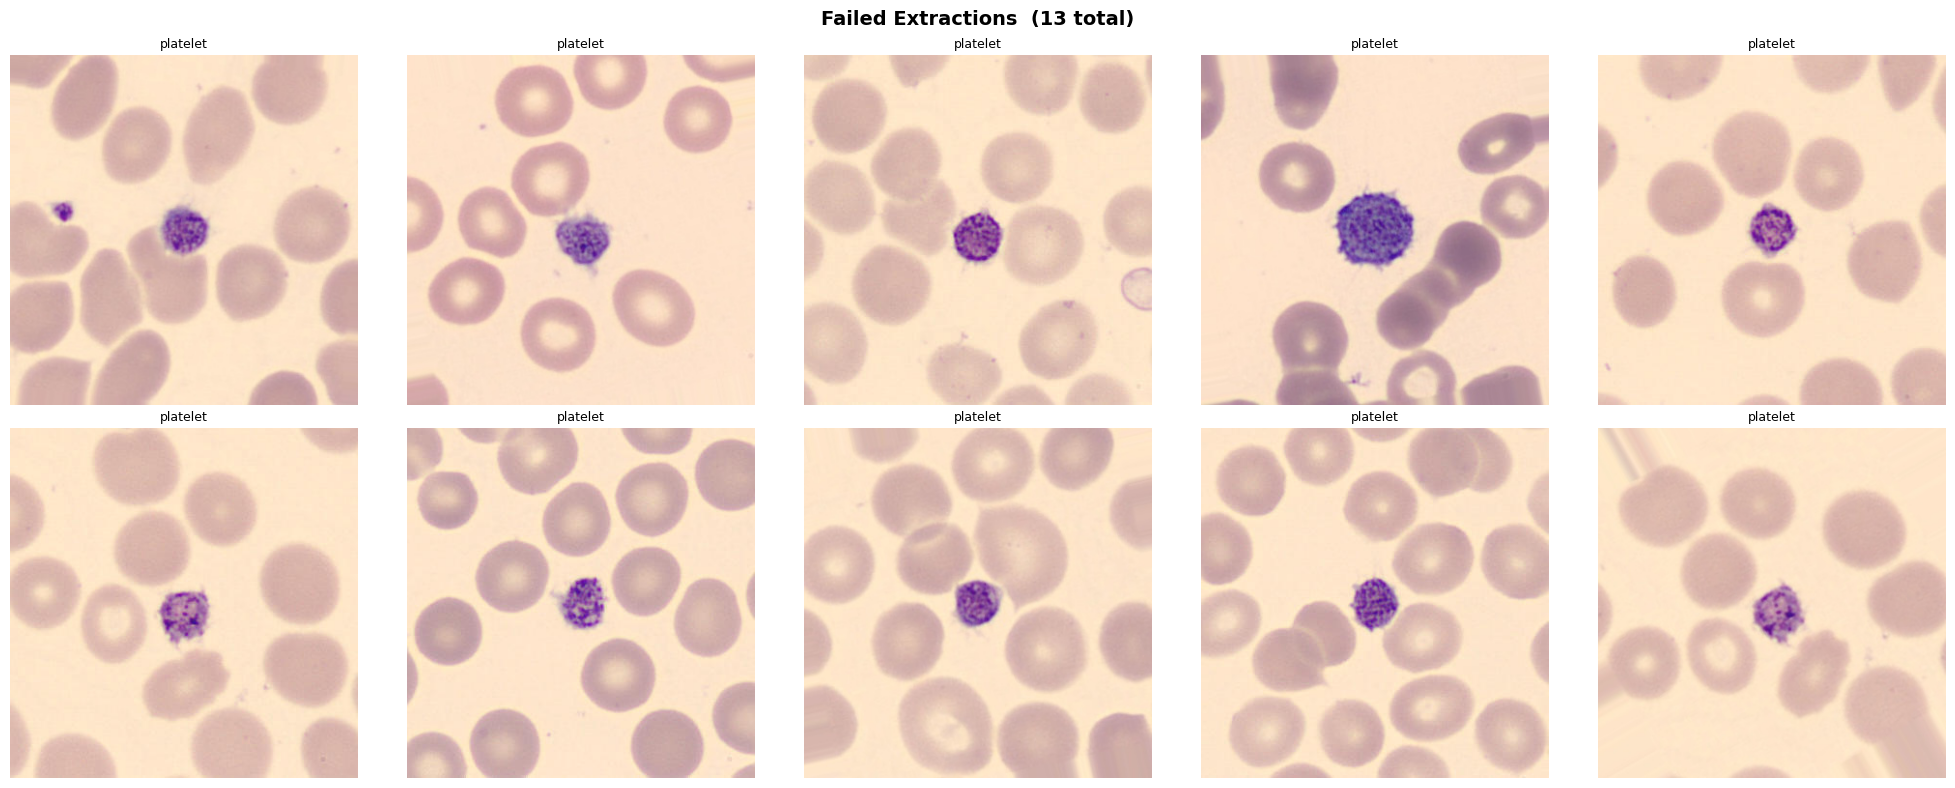

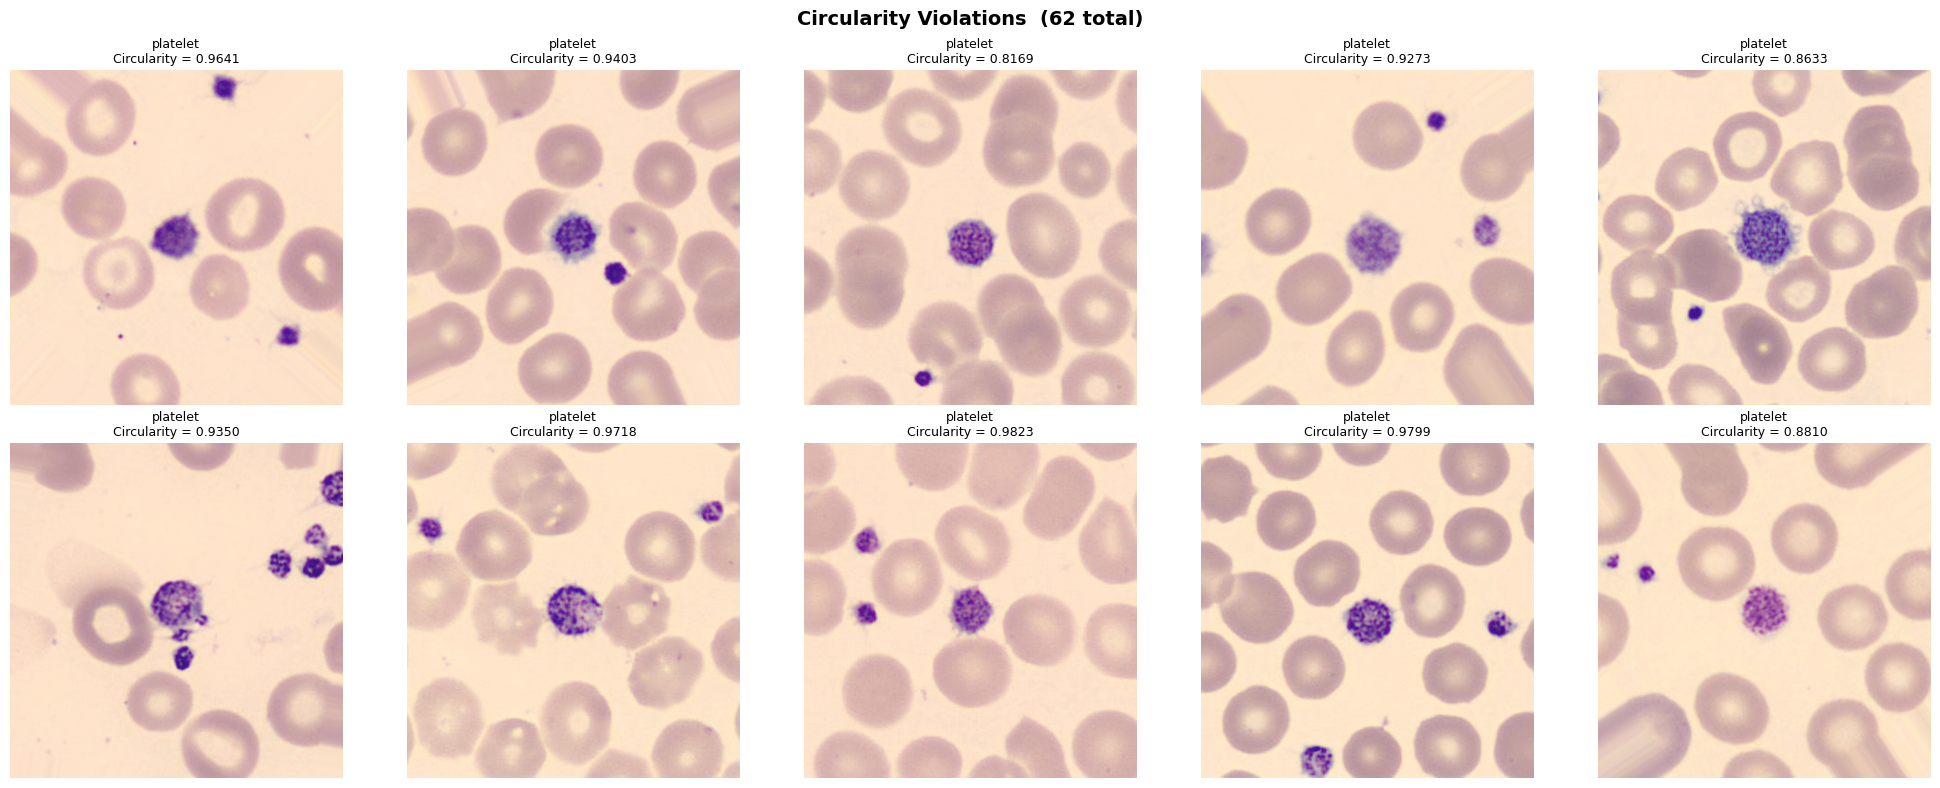

In [7]:
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import random



def display_sample(subset, title, n=10, value_col=None):
    sample = subset.sample(n=min(n, len(subset)), random_state=42)

    fig, axes = plt.subplots(2, 5, figsize=(20, 8))
    fig.suptitle(f"{title}  ({len(subset)} total)", fontsize=14, fontweight='bold')

    for ax, (_, row) in zip(axes.flat, sample.iterrows()):
        img = cv2.imread(row['Filepath'])
        if img is not None:
            ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        else:
            ax.set_facecolor('#1a1a1a')
            ax.text(0.5, 0.5, 'Could not load', ha='center', va='center',
                    color='white', transform=ax.transAxes)

        caption = row['Label']
        if value_col and value_col in row:
            caption += f"\n{value_col} = {row[value_col]:.4f}"
        ax.set_title(caption, fontsize=9)
        ax.axis('off')

    plt.tight_layout()
    plt.show()


display_sample(failed,          title="Failed Extractions")
display_sample(circ_violations, title="Circularity Violations", value_col="Circularity")



What is going on?
Platelets don't have nuclei. When segmentation runs on a picture of a platelet, it finds nothing — it finds the platelet cell body which is small, dense, and roughly circular. The pipeline has no way of knowing the structure it found is not a nucleus — it just sees a compact stained region and assumes it is a nucleus.

The violation occurs because the platelet cell body is so circular. When you have a near-perfect circle and Gaussian smoothing is applied to the contour, the smoothing reduces the perimeter P and the hole-filling flood-fill increases the area A. For a circle, these effects are optimally damaging to the ratio because a circle has the minimum possible perimeter for its area. P² / (4πA) drops fractionally below 1.0, e.g. 0.997.As for the irregular nuclei of monocytes or neutrophils, their measurements are large enough that the effect of smoothing on the perimeter/area ratio is negligible. However, for a platelet cell body which is almost a perfect circle, the measurement is so close that even small perturbations due to smoothing and hole-filling push it just below the theoretical minimum.

In [8]:
df['Circularity'] = df['Circularity'].clip(lower=1.0)
df.to_csv('all_features.csv', index=False)
print("Circularity patched and saved.")

Circularity patched and saved.


In [9]:
df[df[FEATURE_COLS].isna().any(axis=1)]['Label'].unique()

array(['platelet'], dtype=object)

The 3-class multi-Otsu thresholding in feature extraction method divides the soft map into three classes: background, cytoplasm, and nucleus, and keeps the brightest one. This works fine for nucleated cells because the nucleus is the most prominent structure in the soft map.

However, for platelets there is no nucleus. The platelet cell body is small and is likely to be in the mid-class (i.e. weak staining) which would mean it sits at the cytoplasm level. Thus when the pipeline keeps only the top class, it actually finds nothing, resulting in an empty binary mask, no contours are found, and an error is returned instead of the features. This error propagates all the way down and results in the row being written as NaN.
the following code will drop The 8 rows containing null values from the dataset prior to training. This is safe and has no meaningful impact on the analysis given that they represent only 0.03% of the total 28,000 images.



In [10]:
from src.final_feature_extractor import FEATURE_COLS

# see how many rows will be dropped before committing
print(f"Rows before : {len(df):,}")
print(f"Rows to drop: {df[FEATURE_COLS].isna().any(axis=1).sum():,}")

# drop and update 
df = df.dropna(subset=FEATURE_COLS)

print(f"Rows after  : {len(df):,}")

# save
df.to_csv('all_features.csv', index=False)

Rows before : 28,000
Rows to drop: 13
Rows after  : 27,987


In [11]:
validate_features(df)


  FEATURE VALIDATION REPORT  —  27,987 rows
 All 51 feature columns present  (48 colour + 3 shape)
  ✅  Rows with any NaN : 0  (0.00%)
  ✅  Rows with any Inf : 0
  ✅  Circularity     must be ≥ 1.0         violations: 0  (0.0%)
  ✅  Convexity       must be in (0,1]      violations: 0  (0.0%)
  ✅  Solidity        must be in (0,1]      violations: 0  (0.0%)
  ✅  Color ratios < 0    : 0
  ✅  Color ratios > 10   : 0

  Per-class extraction rate:
    ✅  basophil                    3500/3500  (100.0%)
    ✅  eosinophil                  3500/3500  (100.0%)
    ✅  erythroblast                3500/3500  (100.0%)
    ✅  ig                          3500/3500  (100.0%)
    ✅  lymphocyte                  3500/3500  (100.0%)
    ✅  monocyte                    3500/3500  (100.0%)
    ✅  neutrophil                  3500/3500  (100.0%)
    ✅  platelet                    3487/3487  (100.0%)

  Extracted : 27,987 / 27,987  (100.0%)
  ✅ All checks passed.



True